In [1]:
using ITensors, ITensorMPS, Plots, Statistics, StatsBase, GLM, DataFrames, Kneedle, SavitzkyGolay


include(joinpath(@__DIR__, "helper_functions.jl"))

system_params = Dict{String,Any}(
                    "J" => -1.0,
                    "Δ" => -1.0,
                    "μ" => 1.0,
                    "NUM_SWEEPS" => 10,
                    "MAX_BOND_DIM" => 1000,
                    "ACC" => 10^-16
                    )

Dict{String, Any} with 6 entries:
  "Δ"            => -1.0
  "J"            => -1.0
  "μ"            => 1.0
  "MAX_BOND_DIM" => 1000
  "NUM_SWEEPS"   => 10
  "ACC"          => 1.0e-16

In [2]:


run_params_cln = Dict{String, Any}(
    "N" => 40,
    "σ" => 0.00
)

run_params_dis = Dict{String, Any}(
    "N" => 40,
    "σ" => 0.0001
)

filepath = extract_filename_from_system_params(system_params)
MPS_filepath = joinpath(@__DIR__, "data", "perturb_sigma_$(run_params_dis["σ"])_$filepath.hd5")
matches_clean = find_runs_by_params(MPS_filepath, run_params_cln, load_psi = true, instance_selection =:latest)
matches_disordered = find_runs_by_params(MPS_filepath, run_params_dis; load_psi = true, instance_selection =:latest)

psi_clean = matches_clean[1].psi
psi_disordered = matches_disordered[1].psi

spec_clean = get_squared_sorted_schmidt_spectrum_from_mps(psi_clean)
spec_disordered = get_squared_sorted_schmidt_spectrum_from_mps(psi_disordered)

288-element Vector{Float64}:
 0.2476286785444157
 0.20465186064464125
 0.2046518606311878
 0.11511677318520878
 0.11511677316546572
 0.043594581764167174
 0.04359458175261027
 0.010898667879114584
 0.010898667869544
 0.0017437914764259523
 0.0017437914744460176
 0.00017029268728197157
 0.00017029268472459086
 ⋮
 6.857623233892802e-17
 6.841197190945132e-17
 6.497654423100544e-17
 6.44382367385411e-17
 6.059766431195942e-17
 5.917322366919071e-17
 4.9100737877984215e-17
 4.8830643851331776e-17
 3.814119712660896e-17
 3.8116235819944025e-17
 3.190891405226908e-17
 3.189935820228723e-17

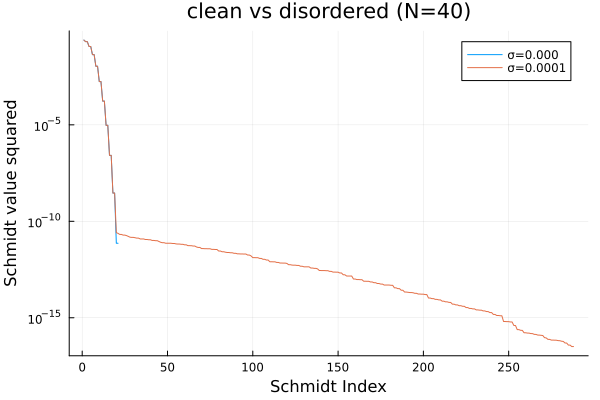

"c:\\Users\\Ethan\\OneDrive - University of Bristol\\Labs\\Y4 Labs\\A_Ethan_code\\A_pertubation\\images\\clean_vs_disordered_N=40_sigma=0.0001.png"

In [3]:
p_clean_vs_disorder = plot(title="clean vs disordered (N=40)", yscale=:log10, xlabel="Schmidt Index", ylabel="Schmidt value squared")

plot!(p_clean_vs_disorder, 1:length(spec_clean), spec_clean, label="σ=0.000")
plot!(p_clean_vs_disorder, 1:length(spec_disordered), spec_disordered, label="σ=$(run_params_dis["σ"])")

display(p_clean_vs_disorder)
savefig(p_clean_vs_disorder, joinpath(@__DIR__, "images", "clean_vs_disordered_N=40_sigma=$(run_params_dis["σ"]).png"))

In [4]:
ξ = inner(psi_clean, psi_disordered)
psi_r = psi_clean - ξ * psi_disordered
normalize!(psi_r)
spec_r = get_squared_sorted_schmidt_spectrum_from_mps(psi_r)
println("Sum: $(sum(spec_r))")




Sum: 1.0000000000000022


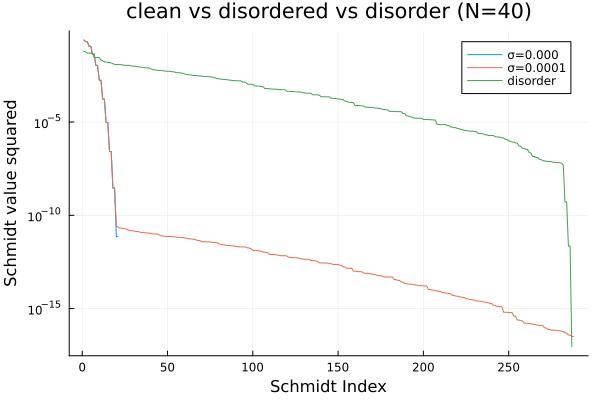

"c:\\Users\\Ethan\\OneDrive - University of Bristol\\Labs\\Y4 Labs\\A_Ethan_code\\A_pertubation\\images_residual\\clean_vs_disordered_vs_disorder_N=40_sigma=0.0001.png"

In [5]:
p_clean_disordered_disorder = plot(title="clean vs disordered vs disorder (N=40)", yscale=:log10, xlabel="Schmidt Index", ylabel="Schmidt value squared")

plot!(p_clean_disordered_disorder, 1:length(spec_clean), spec_clean, label="σ=0.000")
plot!(p_clean_disordered_disorder, 1:length(spec_disordered), spec_disordered, label="σ=$(run_params_dis["σ"])")
plot!(p_clean_disordered_disorder, 1:length(spec_r), spec_r, label="disorder")

display(p_clean_disordered_disorder)
savefig(p_clean_disordered_disorder, joinpath(@__DIR__, "images_residual", "clean_vs_disordered_vs_disorder_N=40_sigma=$(run_params_dis["σ"]).png"))

In [6]:


# Von Neumann Entropy: S = - sum(p * log(p))
function calc_von_neumann(spectrum::Vector{Float64})
    # Filter out zeros or negatives to avoid domain errors in log
    p = filter(x -> x > 1e-20, spectrum)
    return -sum(p .* log.(p))
end

# Renyi Entropy: S_alpha = (1 / (1-alpha)) * log(sum(p^alpha))
function calc_renyi(spectrum::Vector{Float64}, alpha::Float64)
    p = filter(x -> x > 1e-20, spectrum)
    if alpha == 1.0
        return calc_von_neumann(spectrum)
    else
        return (1 / (1 - alpha)) * log(sum(p .^ alpha))
    end
end

# Hartley Entropy (Alpha = 0): S_0 = log(Rank)
function calc_hartley(spectrum::Vector{Float64}; threshold=1e-12)
    # Count singular values larger than a numerical threshold
    rank = count(x -> x > threshold, spectrum)
    return log(rank)
end


calc_hartley (generic function with 1 method)

In [7]:


system_params = Dict{String,Any}(
    "J" => -1.0,
    "Δ" => -1.0,
    "μ" => 1.0,
    "NUM_SWEEPS" => 10,
    "MAX_BOND_DIM" => 1000,
    "ACC" => 10^-16
)

system_sizes = [20, 30, 40, 50, 60] 
sigma_clean = 0.00
sigma_disordered = 0.0001

base_filename = extract_filename_from_system_params(system_params)
function get_mps_path(sigma_val, base_name)
    return joinpath(@__DIR__, "data", "perturb_sigma_$(sigma_val)_$(base_name).hd5")
end

mps_filepath = get_mps_path(sigma_disordered, base_filename)
println("Reading data from: $mps_filepath")

data_clean = Dict("VN" => Float64[], "Renyi" => Float64[], "Hartley" => Float64[])
data_disordered = Dict("VN" => Float64[], "Renyi" => Float64[], "Hartley" => Float64[])
valid_sizes_clean = Int[]
valid_sizes_dis = Int[]


for N in system_sizes
    # --- Clean Case (sigma = 0.00) ---
    try
        # Note: We search in 'mps_filepath' (the disordered file) for the clean params
        run_params = Dict{String, Any}("N" => N, "σ" => sigma_clean)
        
        matches = find_runs_by_params(mps_filepath, run_params, load_psi = true, instance_selection = :latest)
        
        if !isempty(matches)
            spec = get_squared_sorted_schmidt_spectrum_from_mps(matches[1].psi)
            
            push!(data_clean["VN"], calc_von_neumann(spec))
            push!(data_clean["Renyi"], calc_renyi(spec, 0.5))
            push!(data_clean["Hartley"], calc_hartley(spec))
            push!(valid_sizes_clean, N)
        else
            println("No clean data found for N=$N in $mps_filepath")
        end
    catch e
        println("Error processing clean N=$N: $e")
    end

    # --- Disordered Case (sigma = target) ---
    try
        run_params = Dict{String, Any}("N" => N, "σ" => sigma_disordered)
        
        matches = find_runs_by_params(mps_filepath, run_params, load_psi = true, instance_selection = :latest)
        
        if !isempty(matches)
            spec = get_squared_sorted_schmidt_spectrum_from_mps(matches[1].psi)
            
            push!(data_disordered["VN"], calc_von_neumann(spec))
            push!(data_disordered["Renyi"], calc_renyi(spec, 0.5))
            push!(data_disordered["Hartley"], calc_hartley(spec))
            push!(valid_sizes_dis, N)
        else
            println("No disordered data found for N=$N")
        end
    catch e
        println("Error processing disordered N=$N: $e")
    end
end


Reading data from: c:\Users\Ethan\OneDrive - University of Bristol\Labs\Y4 Labs\A_Ethan_code\A_pertubation\data\perturb_sigma_0.0001_Δ=-1.00e+00_J=-1.00e+00_μ=1.00e+00_MAX_BOND_DIM=1000_NUM_SWEEPS=10_ACC=1.00e-16.hd5


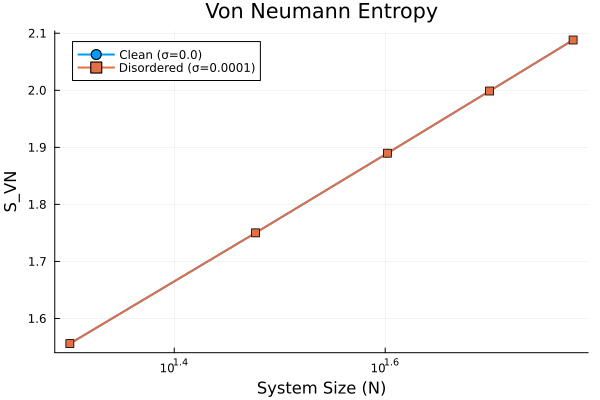

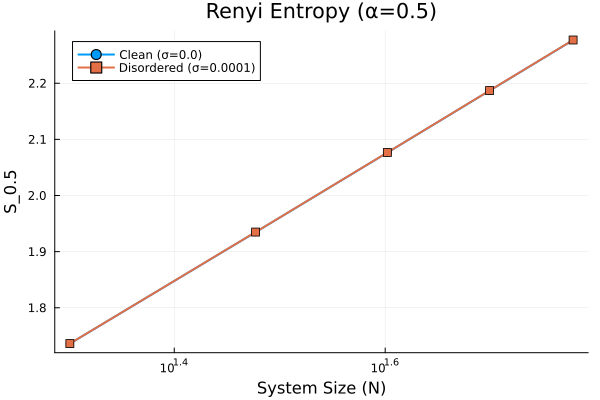

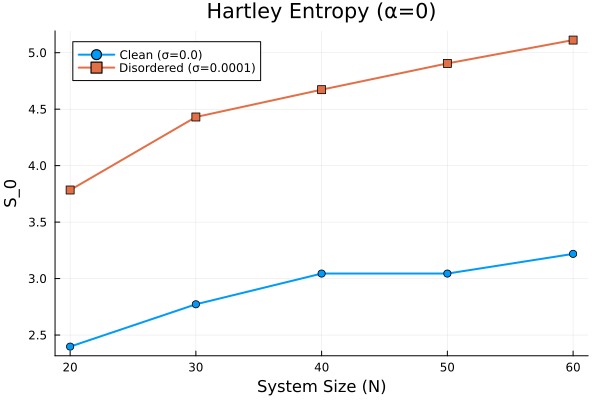

"c:\\Users\\Ethan\\OneDrive - University of Bristol\\Labs\\Y4 Labs\\A_Ethan_code\\A_pertubation\\images_residual\\entropy_hartley_sigma=0.0001.png"

In [8]:
# Plot 1: Von Neumann Entropy
p1 = plot(valid_sizes_clean, data_clean["VN"], xscale=:log10,
    label="Clean (σ=$sigma_clean)", marker=:circle, linewidth=2,
    xlabel="System Size (N)", ylabel="S_VN", title="Von Neumann Entropy")
plot!(p1, valid_sizes_dis, data_disordered["VN"], 
    label="Disordered (σ=$sigma_disordered)", marker=:square, linewidth=2)

# Plot 2: Renyi Entropy (alpha = 0.5)
p2 = plot(valid_sizes_clean, data_clean["Renyi"], xscale=:log10,
    label="Clean (σ=$sigma_clean)", marker=:circle, linewidth=2,
    xlabel="System Size (N)", ylabel="S_0.5", title="Renyi Entropy (α=0.5)")
plot!(p2, valid_sizes_dis, data_disordered["Renyi"], 
    label="Disordered (σ=$sigma_disordered)", marker=:square, linewidth=2)

# Plot 3: Hartley Entropy (alpha = 0)
p3 = plot(valid_sizes_clean, data_clean["Hartley"], sxscale=:log10,
    label="Clean (σ=$sigma_clean)", marker=:circle, linewidth=2,
    xlabel="System Size (N)", ylabel="S_0", title="Hartley Entropy (α=0)")
plot!(p3, valid_sizes_dis, data_disordered["Hartley"], 
    label="Disordered (σ=$sigma_disordered)", marker=:square, linewidth=2)

# Display all plots
display(p1)
display(p2)
display(p3)

savefig(p1, joinpath(@__DIR__, "images_residual", "entropy_vn_sigma=$(sigma_disordered).png"))
savefig(p2, joinpath(@__DIR__, "images_residual", "entropy_alpha_0.5_sigma=$(sigma_disordered).png"))
savefig(p3, joinpath(@__DIR__, "images_residual", "entropy_hartley_sigma=$(sigma_disordered).png"))

In [9]:

system_sizes = [20, 30, 40, 50, 60] 
sigma_clean = 0.00
sigma_disordered = 0.0001

# Initialize containers for residual state data
data_residual = Dict("VN" => Float64[], "Renyi" => Float64[], "Hartley" => Float64[])
valid_sizes_res = Int[]

for N in system_sizes
    try
        # 1. Load the clean state
        clean_params = Dict{String, Any}("N" => N, "σ" => sigma_clean)
        # Note: assuming clean states are in the same or accessible path
        clean_matches = find_runs_by_params(mps_filepath, clean_params, load_psi = true, instance_selection = :latest)
        
        # 2. Load the disordered state
        dis_params = Dict{String, Any}("N" => N, "σ" => sigma_disordered)
        dis_matches = find_runs_by_params(mps_filepath, dis_params, load_psi = true, instance_selection = :latest)
        
        if !isempty(clean_matches) && !isempty(dis_matches)
            psi_clean = clean_matches[1].psi
            psi_disordered = dis_matches[1].psi
            
            # 3. Calculate the residual state logic
            ξ = inner(psi_clean, psi_disordered)
            psi_r = psi_clean - ξ * psi_disordered
            normalize!(psi_r)
            
            # 4. Get spectrum and calculate entropies
            spec_r = get_squared_sorted_schmidt_spectrum_from_mps(psi_r)
            
            push!(data_residual["VN"], calc_von_neumann(spec_r))
            push!(data_residual["Renyi"], calc_renyi(spec_r, 0.5))
            push!(data_residual["Hartley"], calc_hartley(spec_r))
            push!(valid_sizes_res, N)
            
            println("Processed residual state for N=$N. Residual norm sum: $(sum(spec_r))")
        else
            println("Missing data for N=$N (Clean: $(!isempty(clean_matches)), Dis: $(!isempty(dis_matches)))")
        end
    catch e
        println("Error processing N=$N: $e")
    end
end



Processed residual state for N=20. Residual norm sum: 1.000000000000003
Processed residual state for N=30. Residual norm sum: 1.0000000000000018
Processed residual state for N=40. Residual norm sum: 1.0000000000000022
Processed residual state for N=50. Residual norm sum: 0.9999999999999993
Processed residual state for N=60. Residual norm sum: 1.0000000000000009


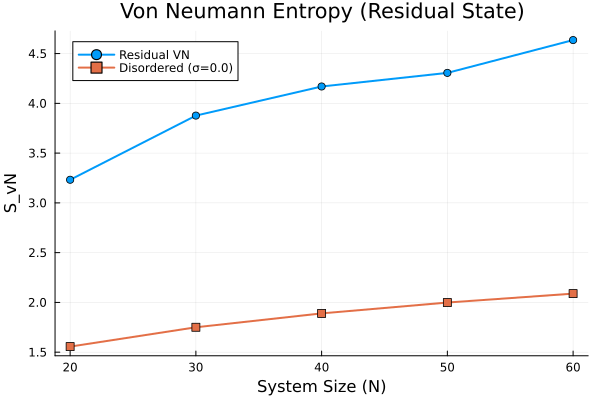

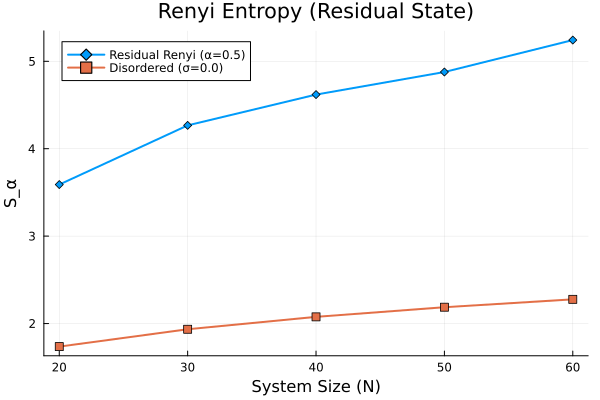

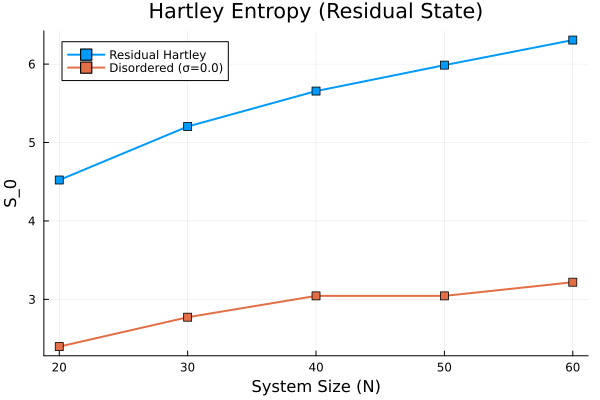

"c:\\Users\\Ethan\\OneDrive - University of Bristol\\Labs\\Y4 Labs\\A_Ethan_code\\A_pertubation\\images_residual\\entropy_hartley_sigma=0.0001_res_clean.png"

In [10]:


p1 = plot(valid_sizes_res, data_residual["VN"], 
    label="Residual VN", marker=:circle, linewidth=2,
    xlabel="System Size (N)", ylabel="S_vN", title="Von Neumann Entropy (Residual State)")
plot!(p1, valid_sizes_dis, data_clean["VN"], 
    label="Disordered (σ=$sigma_clean)", marker=:square, linewidth=2)


p2 = plot(valid_sizes_res, data_residual["Renyi"], 
    label="Residual Renyi (α=0.5)", marker=:diamond, linewidth=2,
    xlabel="System Size (N)", ylabel="S_α", title="Renyi Entropy (Residual State)")
plot!(p2, valid_sizes_dis, data_clean["Renyi"], 
    label="Disordered (σ=$sigma_clean)", marker=:square, linewidth=2)

p3 = plot(valid_sizes_res, data_residual["Hartley"], 
    label="Residual Hartley", marker=:square, linewidth=2,
    xlabel="System Size (N)", ylabel="S_0", title="Hartley Entropy (Residual State)")
plot!(p3, valid_sizes_dis, data_clean["Hartley"], 
    label="Disordered (σ=$sigma_clean)", marker=:square, linewidth=2)

display(p1)
display(p2)
display(p3)

savefig(p1, joinpath(@__DIR__, "images_residual", "entropy_vn_sigma=$(sigma_disordered)_res_clean.png"))
savefig(p2, joinpath(@__DIR__, "images_residual", "entropy_alpha_0.5_sigma=$(sigma_disordered)_res_clean.png"))
savefig(p3, joinpath(@__DIR__, "images_residual", "entropy_hartley_sigma=$(sigma_disordered)_res_clean.png"))

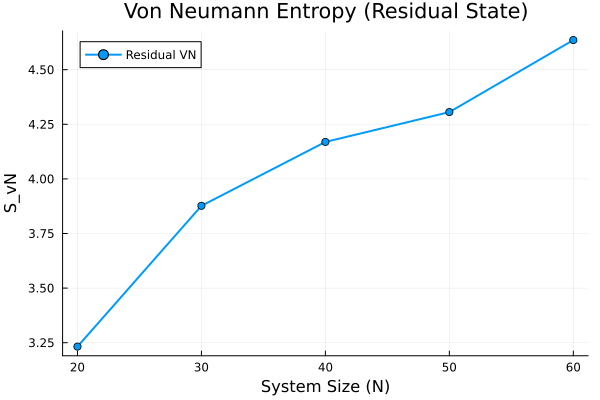

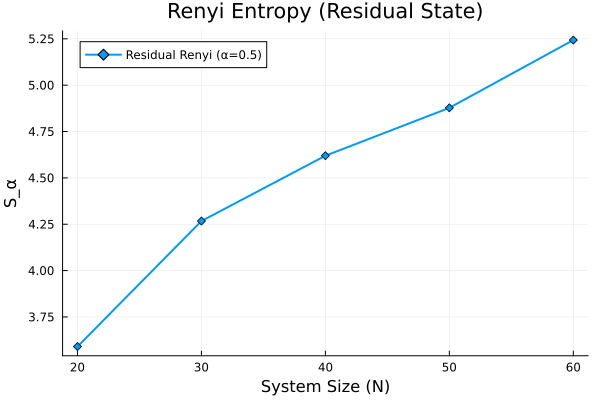

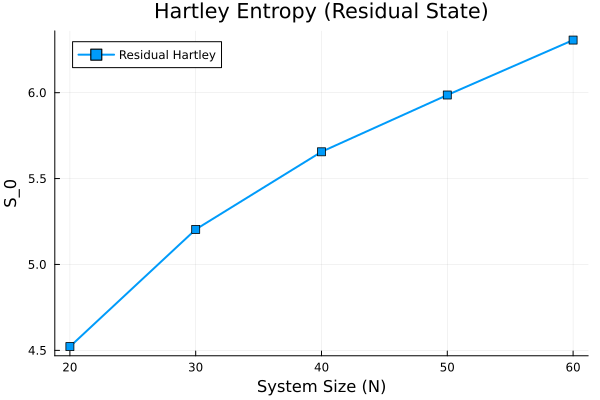

"c:\\Users\\Ethan\\OneDrive - University of Bristol\\Labs\\Y4 Labs\\A_Ethan_code\\A_pertubation\\images_residual\\entropy_hartley_sigma=0.0001_res.png"

In [11]:


p1 = plot(valid_sizes_res, data_residual["VN"], 
    label="Residual VN", marker=:circle, linewidth=2,
    xlabel="System Size (N)", ylabel="S_vN", title="Von Neumann Entropy (Residual State)")



p2 = plot(valid_sizes_res, data_residual["Renyi"], 
    label="Residual Renyi (α=0.5)", marker=:diamond, linewidth=2,
    xlabel="System Size (N)", ylabel="S_α", title="Renyi Entropy (Residual State)")


p3 = plot(valid_sizes_res, data_residual["Hartley"], 
    label="Residual Hartley", marker=:square, linewidth=2,
    xlabel="System Size (N)", ylabel="S_0", title="Hartley Entropy (Residual State)")


display(p1)
display(p2)
display(p3)

savefig(p1, joinpath(@__DIR__, "images_residual", "entropy_vn_sigma=$(sigma_disordered)_res.png"))
savefig(p2, joinpath(@__DIR__, "images_residual", "entropy_alpha_0.5_sigma=$(sigma_disordered)_res.png"))
savefig(p3, joinpath(@__DIR__, "images_residual", "entropy_hartley_sigma=$(sigma_disordered)_res.png"))

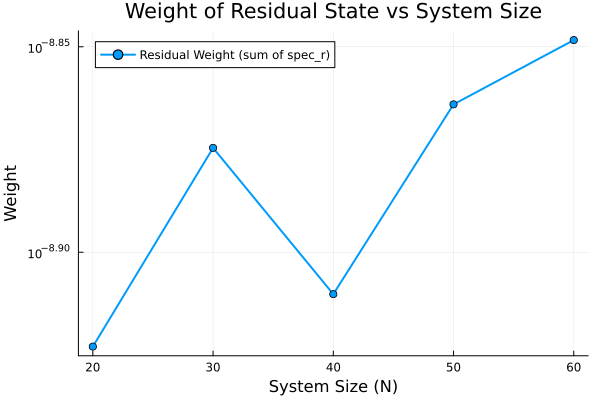

In [12]:
residual_weights = []

for N in valid_sizes_res
    # Set parameters for the disordered run
    run_params_dis = Dict{String, Any}("N" => N, "σ" => 0.0001)
    matches_dis = find_runs_by_params(MPS_filepath, run_params_dis; load_psi = true, instance_selection = :latest)
    
    if !isempty(matches_dis)
        psi_dis = matches_dis[1].psi

        
        run_params_cln = Dict{String, Any}("N" => N, "σ" => 0.00)
        matches_cln = find_runs_by_params(MPS_filepath, run_params_cln; load_psi = true, instance_selection = :latest)
        
        if !isempty(matches_cln)
            psi_cln = matches_cln[1].psi
            psi_r = psi_dis - inner(psi_cln, psi_dis) * psi_cln
            spec_r = get_squared_sorted_schmidt_spectrum_from_mps(psi_r)
            push!(residual_weights, sum(spec_r))
        else
            push!(residual_weights, NaN)
        end
    else
        push!(residual_weights, NaN)
    end
end

p_weight = plot(valid_sizes_res, residual_weights, 
    label="Residual Weight (sum of spec_r)", marker=:circle, linewidth=2,
    xlabel="System Size (N)", ylabel="Weight", 
    title="Weight of Residual State vs System Size",
    yscale=:log10)

display(p_weight)

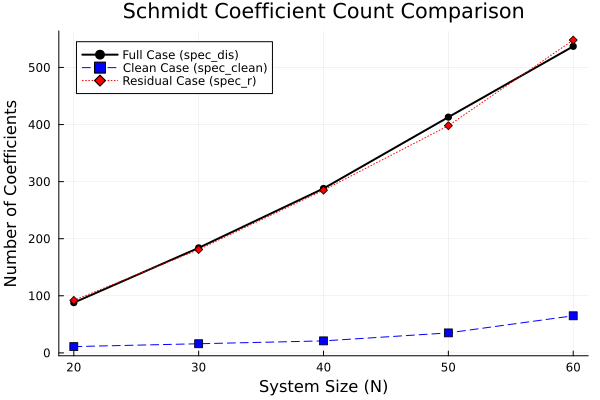

In [13]:
# Initialize arrays for coefficient counts
num_coeffs_clean = []
num_coeffs_residual = []
num_coeffs_full = []

for N in valid_sizes_res
    run_params_cln = Dict{String, Any}("N" => N, "σ" => 0.00)
    run_params_dis = Dict{String, Any}("N" => N, "σ" => 0.0001)
    
    matches_cln = find_runs_by_params(MPS_filepath, run_params_cln; load_psi = true, instance_selection = :latest)
    matches_dis = find_runs_by_params(MPS_filepath, run_params_dis; load_psi = true, instance_selection = :latest)
    
    if !isempty(matches_cln) && !isempty(matches_dis)
        psi_cln = matches_cln[1].psi
        psi_dis = matches_dis[1].psi
        
        # 1. Clean Case
        spec_cln = get_squared_sorted_schmidt_spectrum_from_mps(psi_cln)
        push!(num_coeffs_clean, length(spec_cln))
        
        # 2. Full Case (Disordered)
        spec_dis = get_squared_sorted_schmidt_spectrum_from_mps(psi_dis)
        push!(num_coeffs_full, length(spec_dis))
        
        # 3. Residual Case (spec_r from psi_r)
        psi_r = psi_dis - inner(psi_cln, psi_dis) * psi_cln
        spec_r = get_squared_sorted_schmidt_spectrum_from_mps(psi_r)
        push!(num_coeffs_residual, length(spec_r))
    else
        push!(num_coeffs_clean, NaN)
        push!(num_coeffs_full, NaN)
        push!(num_coeffs_residual, NaN)
    end
end

# Plot all three cases on the same graph
p_comp = plot(valid_sizes_res, num_coeffs_full, 
    label="Full Case (spec_dis)", marker=:circle, color=:black, linewidth=2)

plot!(p_comp, valid_sizes_res, num_coeffs_clean, 
    label="Clean Case (spec_clean)", marker=:square, color=:blue, linestyle=:dash)

plot!(p_comp, valid_sizes_res, num_coeffs_residual, 
    label="Residual Case (spec_r)", marker=:diamond, color=:red, linestyle=:dot,
    xlabel="System Size (N)", ylabel="Number of Coefficients", 
    title="Schmidt Coefficient Count Comparison", legend=:topleft)

display(p_comp)

In [14]:
target_N = 40

run_params_cln = Dict{String, Any}("N" => target_N, "σ" => 0.00)
run_params_dis = Dict{String, Any}("N" => target_N, "σ" => 0.0001)

matches_cln = find_runs_by_params(mps_filepath, run_params_cln, load_psi = true, instance_selection = :latest)
matches_dis = find_runs_by_params(mps_filepath, run_params_dis; load_psi = true, instance_selection = :latest)

local_psi_cln = matches_cln[1].psi
local_psi_dis = matches_dis[1].psi

spec_cln = get_squared_sorted_schmidt_spectrum_from_mps(local_psi_cln)

# Calculate residual state
ξ = inner(local_psi_cln, local_psi_dis)
psi_r = local_psi_dis - ξ * local_psi_cln
spec_r = get_squared_sorted_schmidt_spectrum_from_mps(psi_r)

len_cln = length(spec_cln)
len_res = length(spec_r)
idx_cln = 1:len_cln
idx_res = (len_cln + 1):(len_cln + len_res)


22:306

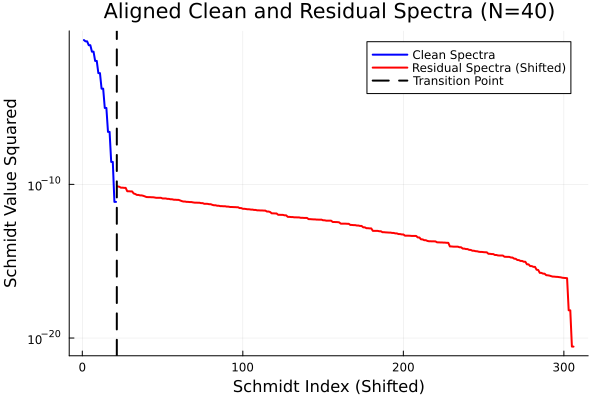

In [15]:


p_aligned = plot(yscale=:log10, 
    title="Aligned Clean and Residual Spectra (N=$target_N)",
    xlabel="Schmidt Index (Shifted)", 
    ylabel="Schmidt Value Squared",
    legend=:topright, grid=true)

plot!(p_aligned, idx_cln, spec_cln, label="Clean Spectra", color=:blue, linewidth=2)
plot!(p_aligned, idx_res, spec_r, label="Residual Spectra (Shifted)", color=:red, linewidth=2)

vline!(p_aligned, [len_cln + 0.5], label="Transition Point", color=:black, linestyle=:dash, linewidth=2)
display(p_aligned)


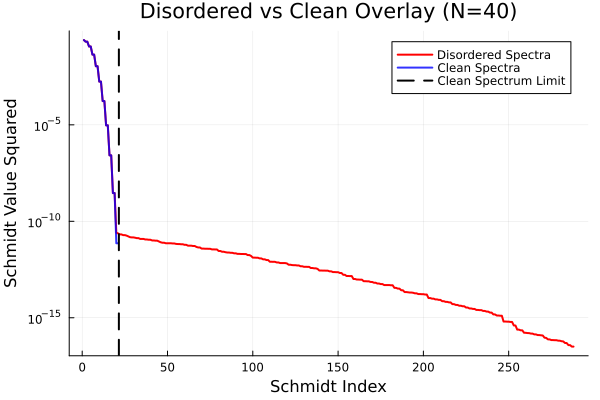

In [16]:

spec_dis = get_squared_sorted_schmidt_spectrum_from_mps(local_psi_dis)

p_simple = plot(1:length(spec_dis), spec_dis, 
    yscale=:log10, 
    label="Disordered Spectra", 
    color=:red, 
    linewidth=2,
    title="Disordered vs Clean Overlay (N=$target_N)",
    xlabel="Schmidt Index", 
    ylabel="Schmidt Value Squared",
    grid=true)

plot!(p_simple, 1:length(spec_cln), spec_cln, 
    label="Clean Spectra", 
    color=:blue, 
    linewidth=2,
    alpha=0.8) # Slight transparency to see overlap

vline!(p_simple, [length(spec_cln) + 0.5], 
    label="Clean Spectrum Limit", 
    color=:black, 
    linestyle=:dash, 
    linewidth=2)

display(p_simple)


Closest value found at Clean Index: 20
Clean value: 7.254445750774561e-12 vs Residual start: 7.372228056854358e-11


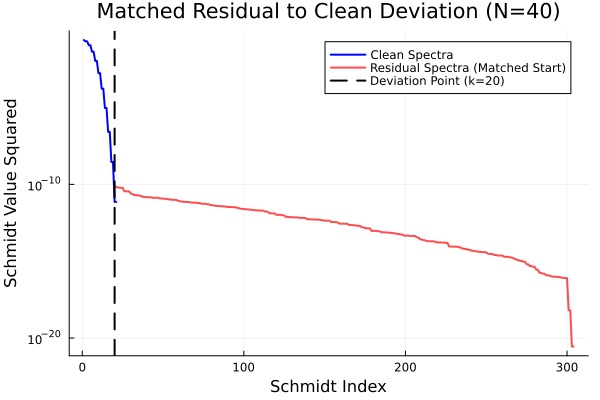

"c:\\Users\\Ethan\\OneDrive - University of Bristol\\Labs\\Y4 Labs\\A_Ethan_code\\A_pertubation\\images_residual\\matched_residual_clean_N=40.png"

In [17]:


# Find the index in spec_cln closest to spec_r[1]
first_res_val = spec_r[1]
# We look for the minimum absolute difference
deviation_idx = argmin(abs.(spec_cln .- first_res_val))

println("Closest value found at Clean Index: ", deviation_idx)
println("Clean value: ", spec_cln[deviation_idx], " vs Residual start: ", first_res_val)

# Define the shifted indices for the residual state
# It starts at the deviation_idx and extends forward
idx_cln = 1:length(spec_cln)
idx_res_shifted = deviation_idx:(deviation_idx + length(spec_r) - 1)

p_matched = plot(yscale=:log10, 
    title="Matched Residual to Clean Deviation (N=$target_N)",
    xlabel="Schmidt Index", 
    ylabel="Schmidt Value Squared",
    legend=:topright, 
    grid=true)

# Plot Clean (Blue)
plot!(p_matched, idx_cln, spec_cln, 
    label="Clean Spectra", color=:blue, linewidth=2)

# Plot Residual (Red) starting at the deviation index
plot!(p_matched, idx_res_shifted, spec_r, 
    label="Residual Spectra (Matched Start)", color=:red, linewidth=2, alpha=0.7)

# Add vertical dashed line at the deviation index
vline!(p_matched, [deviation_idx], 
    label="Deviation Point (k=$deviation_idx)", 
    color=:black, linestyle=:dash, linewidth=2)

display(p_matched)
savefig(p_matched, joinpath(@__DIR__, "images_residual", "matched_residual_clean_N=$(target_N).png"))


# Bounding the error

we have 
$$
\ket{\psi_{\sigma}} = \xi \ket{\psi_{0}} + (1-\xi) \ket{\psi_{r}}   
$$

define the truncation error from the residual state 
$$
\varepsilon^2 \propto \text{truncation error of } \ket{\psi_\text{res}} = \sum_{i}^{\chi} \lambda_i^2
$$

so we can work out total error for each state dep on $(N, \sigma)$ by finding $\ket{\psi_r}$ as we did earlier if we were to approximate it with the truncated state.

Mathematically, the residual state $|\psi_r\rangle$ is the part of the disordered state $|\psi_{dis}\rangle$ that is orthogonal to the clean state $|\psi_{cln}\rangle$. It is defined as:$$|\psi_r\rangle = |\psi_{dis}\rangle - \langle \psi_{cln} | \psi_{dis} \rangle |\psi_{cln}\rangle$$

In [18]:
function get_psi_r(psi_cln::MPS, psi_dis::MPS; normalize::Bool=false, cutoff::Float64=1e-12)
    ξ = inner(psi_cln, psi_dis)
    

    psi_cln_scaled = copy(psi_cln)
    
    # In ITensors, scaling an MPS is done by multiplying one of its tensors (usually the first one)
    psi_cln_scaled[1] .*= -ξ
    

    psi_res = +(psi_dis, psi_cln_scaled; cutoff=cutoff)
    
    if normalize

        nrm = norm(psi_res)
        if nrm > 0
            psi_res[1] ./= nrm
        end
    end
    
    return psi_res
end

get_psi_r (generic function with 1 method)

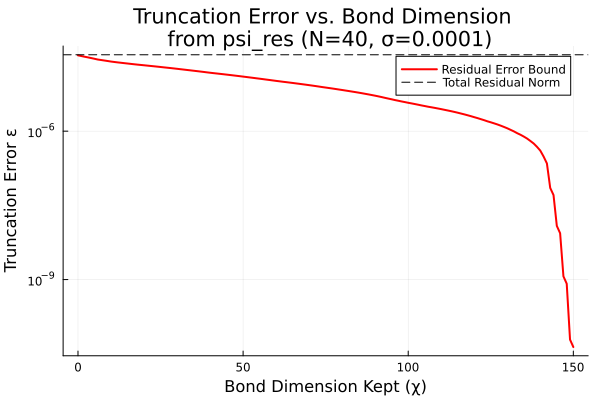

In [19]:
N, σ = 40, 0.0001 
system_params = Dict{String,Any}(
    "J" => -1.0, "Δ" => -1.0, "μ" => 1.0,
    "NUM_SWEEPS" => 10, "MAX_BOND_DIM" => 1000, "ACC" => 1.0e-16
)

run_params_dis = Dict{String, Any}(
    "N" => N,
    "σ" => σ
)


fp_suffix = extract_filename_from_system_params(system_params)
fp = joinpath(@__DIR__, "data", "perturb_sigma_$(run_params_dis["σ"])_$(fp_suffix).hd5")

psi_cln = find_runs_by_params(fp, Dict{String, Any}("N"=>N, "σ"=>0.00); load_psi=true, instance_selection=:latest)[1].psi
psi_dis = find_runs_by_params(fp, run_params_dis; load_psi=true, instance_selection=:latest)[1].psi

ξ = inner(psi_cln, psi_dis)
psi_res = get_psi_r(psi_cln, psi_dis; normalize=false) 

spec_res = get_squared_sorted_schmidt_spectrum_from_mps(psi_res)

# Calculate Truncation Error (ε) vs Bond Dimension Kept (χ)
# ε = sqrt(sum of discarded eigenvalues)
max_chi = length(spec_res)
chis = 0:(max_chi - 1)
epsilons = [sqrt(abs(sum(spec_res[k+1:end]))) for k in chis] # abs to prevent tiny precision negatives

p_trunc = plot(chis, epsilons,
               yscale=:log10,
               lw=2,
               lc=:red,
               title="Truncation Error vs. Bond Dimension \n from psi_res (N=$N, σ=$σ)",
               xlabel="Bond Dimension Kept (χ)",
               ylabel="Truncation Error ε",
               label="Residual Error Bound")

res_norm = sqrt(abs(1 - abs(ξ)^2))
hline!([res_norm], linestyle=:dash, lc=:black, label="Total Residual Norm")

display(p_trunc)

Data for N=60 not found. Skipping...


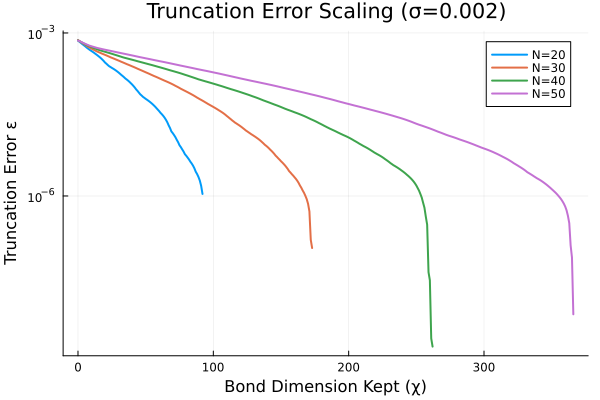

In [20]:
σ = 0.002

p_all_n = plot(title="Truncation Error Scaling (σ=$σ)",
               xlabel="Bond Dimension Kept (χ)",
               ylabel="Truncation Error ε", 
               yscale=:log10, 
               legend=:topright)

for (i, N) in enumerate([20, 30, 40, 50, 60])
    system_params = Dict{String,Any}(
        "J" => -1.0, "Δ" => -1.0, "μ" => 1.0,
        "NUM_SWEEPS" => 10, "MAX_BOND_DIM" => 1000, "ACC" => 1.0e-16
    )
    
    fp_suffix = extract_filename_from_system_params(system_params)
    fp = joinpath(@__DIR__, "data", "perturb_sigma_$(σ)_$(fp_suffix).hd5")

    cln_runs = find_runs_by_params(fp, Dict{String, Any}("N"=>N, "σ"=>0.00); load_psi=true, instance_selection=:latest)
    dis_runs = find_runs_by_params(fp, Dict{String, Any}("N"=>N, "σ"=>σ); load_psi=true, instance_selection=:latest)
    
    if isempty(cln_runs) || isempty(dis_runs)
        println("Data for N=$N not found. Skipping...")
        continue
    end
    
    psi_cln = cln_runs[1].psi
    psi_dis = dis_runs[1].psi

    psi_res = get_psi_r(psi_cln, psi_dis; normalize=false)
    spec_res = get_squared_sorted_schmidt_spectrum_from_mps(psi_res)
    
    max_chi = length(spec_res)
    epsilons = [sqrt(abs(sum(spec_res[k+1:end]))) for k in 0:max_chi-1]

    plot!(p_all_n, 0:max_chi-1, epsilons, label="N=$N", color=i, lw=2)
end

display(p_all_n)

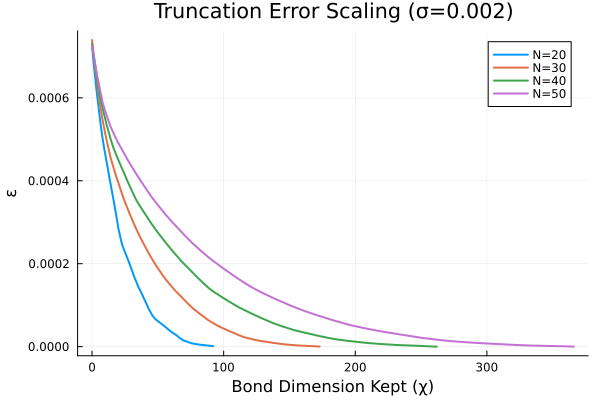

In [21]:
σ = 0.002

p_all_n = plot(title="Truncation Error Scaling (σ=$σ)",
               xlabel="Bond Dimension Kept (χ)",
               ylabel="ε", 
               legend=:topright)

for (i, N) in enumerate([20, 30, 40, 50, 60])
    system_params = Dict{String,Any}(
        "J" => -1.0, "Δ" => -1.0, "μ" => 1.0,
        "NUM_SWEEPS" => 10, "MAX_BOND_DIM" => 1000, "ACC" => 1.0e-16
    )
    
    fp_suffix = extract_filename_from_system_params(system_params)
    fp = joinpath(@__DIR__, "data", "perturb_sigma_$(σ)_$(fp_suffix).hd5")

    cln_runs = find_runs_by_params(fp, Dict{String, Any}("N"=>N, "σ"=>0.00); load_psi=true, instance_selection=:latest)
    dis_runs = find_runs_by_params(fp, Dict{String, Any}("N"=>N, "σ"=>σ); load_psi=true, instance_selection=:latest)
    
    if isempty(cln_runs) || isempty(dis_runs)
        continue
    end
    
    psi_cln = cln_runs[1].psi
    psi_dis = dis_runs[1].psi

    psi_res = get_psi_r(psi_cln, psi_dis; normalize=false)
    spec_res = get_squared_sorted_schmidt_spectrum_from_mps(psi_res)
    
    max_chi = length(spec_res)
    epsilons = [sqrt(abs(sum(spec_res[k+1:end]))) for k in 0:max_chi-1]

    plot!(p_all_n, 0:max_chi-1, epsilons, label="N=$N", color=i, lw=2)
end

display(p_all_n)

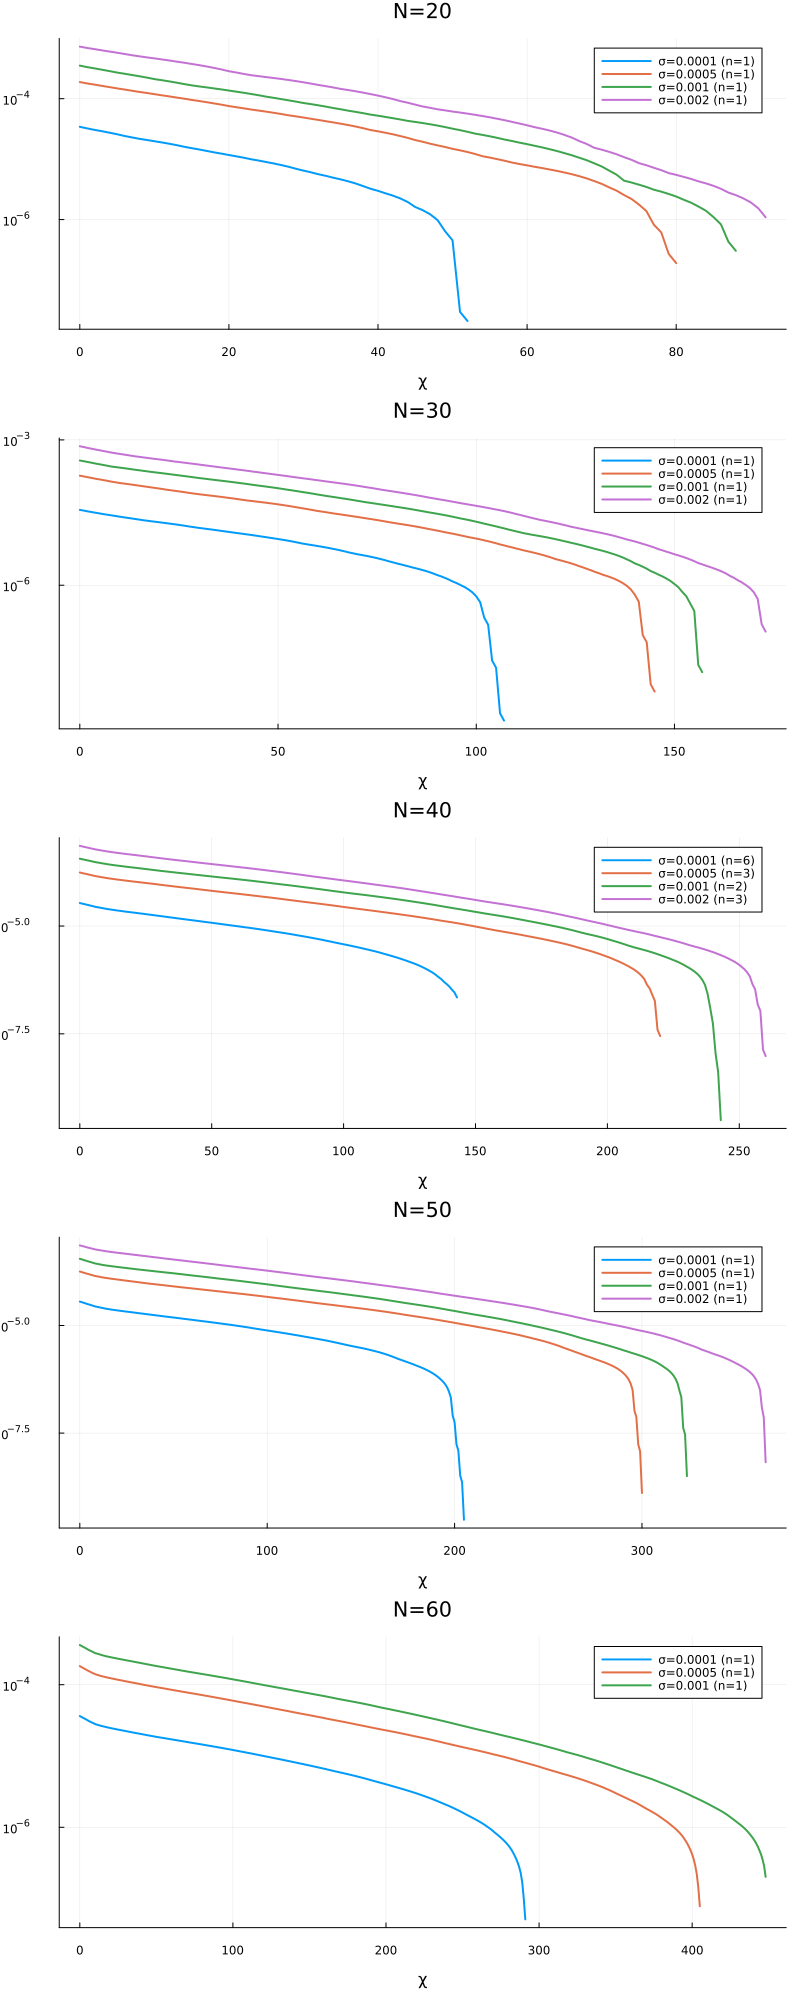

In [22]:
using ITensors, ITensorMPS, Plots, Statistics

N_vals = 20:10:60
sigma_vals = [0.0001, 0.0005, 0.001, 0.002]

plots = []

for N in N_vals
    p = plot(title="N=$N",
             yscale=:log10,
             xlabel="χ",
             ylabel="ε",
             legend=:topright,
             lw=2)

    for sigma in sigma_vals
        system_params = Dict{String,Any}(
            "J" => -1.0, "Δ" => -1.0, "μ" => 1.0,
            "NUM_SWEEPS" => 10, "MAX_BOND_DIM" => 1000, "ACC" => 10^-16
        )
        fp_suffix = extract_filename_from_system_params(system_params)
        fp = joinpath(@__DIR__, "data", "perturb_sigma_$(sigma)_$(fp_suffix).hd5")

        cln_data = find_runs_by_params(fp, Dict{String, Any}("N"=>N, "σ"=>0.00); load_psi=true, instance_selection=:all)
        dis_data = find_runs_by_params(fp, Dict{String, Any}("N"=>N, "σ"=>sigma); load_psi=true, instance_selection=:all)

        if isempty(cln_data) || isempty(dis_data)
            continue
        end

        num_instances = min(length(cln_data), length(dis_data))
        epsilon_curves = []

        for i in 1:num_instances
            psi_cln = cln_data[i].psi
            psi_dis = dis_data[i].psi
            psi_res = get_psi_r(psi_cln, psi_dis; normalize=false)
            spec_res = get_squared_sorted_schmidt_spectrum_from_mps(psi_res)

            max_chi = length(spec_res)
            epsilons = [sqrt(sum(spec_res[k+1:end])) for k in 0:max_chi-1]

            push!(epsilon_curves, epsilons)
        end

        # Average over instances
        min_length = minimum(length.(epsilon_curves))
        avg_epsilons = [mean([curve[i] for curve in epsilon_curves]) for i in 1:min_length]

        plot!(p, 0:min_length-1, avg_epsilons,
              label="σ=$sigma (n=$num_instances)",
              lw=2)
    end

    push!(plots, p)
end

plot(plots..., layout=(length(N_vals), 1), size=(800, 400*length(N_vals)))

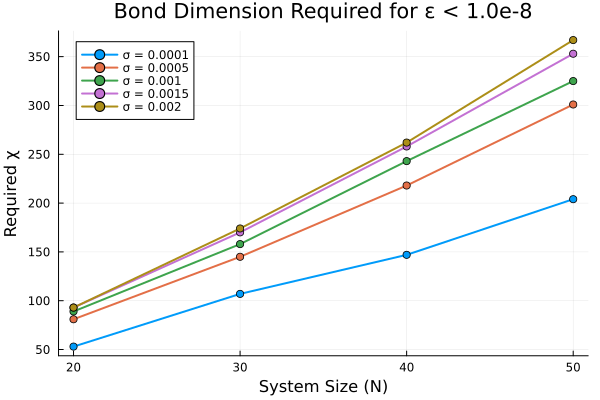

In [23]:
target_epsilon = 1e-8
N_vals = [20, 30, 40, 50]
σs = [0.0001, 0.0005, 0.001, 0.0015, 0.002]

pl = plot(title="Bond Dimension Required for ε < $target_epsilon",
          xlabel="System Size (N)",
          ylabel="Required χ",
          legend=:topleft,
          grid=true)

for σ in σs
    current_sigma_chis = Int[]

    for N in N_vals
        system_params = Dict{String,Any}(
            "J" => -1.0, "Δ" => -1.0, "μ" => 1.0,
            "NUM_SWEEPS" => 10, "MAX_BOND_DIM" => 1000, "ACC" => 10^-16
        )

        fp_suffix = extract_filename_from_system_params(system_params)
        fp = joinpath(@__DIR__, "data", "perturb_sigma_$(σ)_$(fp_suffix).hd5")

        cln_runs = find_runs_by_params(fp, Dict{String, Any}("N"=>N, "σ"=>0.00); load_psi=true, instance_selection=:latest)
        dis_runs = find_runs_by_params(fp, Dict{String, Any}("N"=>N, "σ"=>σ); load_psi=true, instance_selection=:latest)

        if isempty(cln_runs) || isempty(dis_runs)
            @warn "Data missing for N=$N, σ=$σ"
            push!(current_sigma_chis, 0)
            continue
        end

        psi_cln = cln_runs[1].psi
        psi_dis = dis_runs[1].psi


        psi_res = get_psi_r(psi_cln, psi_dis; normalize=false)
        spec_res = get_squared_sorted_schmidt_spectrum_from_mps(psi_res)

        max_chi = length(spec_res)
        epsilons = [sqrt(sum(spec_res[k+1:end])) for k in 0:max_chi-1]

        idx = findfirst(e -> e < target_epsilon, epsilons)

        # if no index is found (even keeping all is > target), use max_chi
        push!(current_sigma_chis, idx === nothing ? max_chi : idx)
    end

    plot!(pl, N_vals, current_sigma_chis,
          marker=:circle,
          label="σ = $σ",
          lw=2)
end

display(pl)

# Looking at Renyi entropies

In [24]:
function calculate_renyi_entropy_from_spectrum(spec::Vector{Float64}, α::Float64)
    p_nonzero = filter(x -> x > 1e-16, spec)
    

    
    if abs(α - 1.0) < 1e-10
        return -sum(p * log(p) for p in p_nonzero)
    else
        return log(sum(p_nonzero.^α)) / (1 - α)
    end
end

calculate_renyi_entropy_from_spectrum (generic function with 1 method)

In [25]:
using LsqFit

function plot_renyi(N_vals, sigma_vals, α)
    system_params = Dict{String,Any}(
        "J" => -1.0, "Δ" => -1.0, "μ" => 1.0,
        "NUM_SWEEPS" => 10, "MAX_BOND_DIM" => 1000, "ACC" => 10^-16
    )

    p = plot(title="ren ent (alpha=$α) vs N",
            xlabel="N",
            ylabel="S_$α",
            legend=:bottomright,
            lw=2,
            marker=:circle,
            markersize=4)

    for (color_idx, sigma) in enumerate(sigma_vals)
        N_list = Int[]
        S_list = Float64[]
        S_err_list = Float64[]

        for N in N_vals
            fp_suffix = extract_filename_from_system_params(system_params)
            fp = joinpath(@__DIR__, "data", "perturb_sigma_$(sigma)_$(fp_suffix).hd5")

            cln_data = find_runs_by_params(fp, Dict{String, Any}("N"=>N, "σ"=>0.00); load_psi=true, instance_selection=:all)
            dis_data = find_runs_by_params(fp, Dict{String, Any}("N"=>N, "σ"=>sigma); load_psi=true, instance_selection=:all)

            if isempty(cln_data) || isempty(dis_data)
                @warn "Missing data for N=$N, σ=$sigma"
                continue
            end

            num_instances = min(length(cln_data), length(dis_data))
            entropies = Float64[]

            for i in 1:num_instances
                psi_cln = cln_data[i].psi
                psi_dis = dis_data[i].psi
                psi_r = get_psi_r(psi_cln, psi_dis; normalize=true)

                spec = get_squared_sorted_schmidt_spectrum_from_mps(psi_r)
                S = calculate_renyi_entropy_from_spectrum(spec, α)

                push!(entropies, S)
            end

            avg_S = mean(entropies)
            err_S = length(entropies) > 1 ? std(entropies) / sqrt(length(entropies)) : 0.0

            push!(N_list, N)
            push!(S_list, avg_S)
            push!(S_err_list, err_S)
        end

        if length(N_list) < 2
            continue
        end

        # fit power law: S = A * N^κ
        # Using log-log fit: log(S) = log(A) + κ*log(N)
        model(x, p) = p[1] .* x.^p[2]  # p[1] = A, p[2] = κ
        p0 = [1.0, 1.0]
        weights = [err > 0 ? 1/err^2 : 1.0 for err in S_err_list]

        try
            fit_result = curve_fit(model, Float64.(N_list), S_list, weights, p0)
            A, κ = coef(fit_result)


            errors = stderror(fit_result)
            κ_err = errors[2]

            scatter!(p, N_list, S_list,
                    yerror=S_err_list,
                    label="σ=$sigma (κ=$(round(κ, digits=3))±$(round(κ_err, digits=3)))",
                    color=color_idx,
                    markersize=4)

            N_fit = range(minimum(N_list), maximum(N_list), length=100)
            S_fit = model(N_fit, [A, κ])
            plot!(p, N_fit, S_fit,
                  label=false,
                  color=color_idx,
                  linestyle=:dash,
                  lw=2)

        catch e
            @warn "Fit failed for σ=$sigma: $e"
            scatter!(p, N_list, S_list,
                    yerror=S_err_list,
                    label="σ=$sigma (fit failed)",
                    color=color_idx,
                    markersize=4)
        end
    end

    return p
end

plot_renyi (generic function with 1 method)

┌ Warning: Missing data for N=60, σ=0.002
└ @ Main In[25]:30
┌ Warning: Missing data for N=60, σ=0.002
└ @ Main In[25]:30
┌ Warning: Missing data for N=60, σ=0.002
└ @ Main In[25]:30
┌ Warning: Missing data for N=60, σ=0.002
└ @ Main In[25]:30
┌ Warning: Missing data for N=60, σ=0.002
└ @ Main In[25]:30


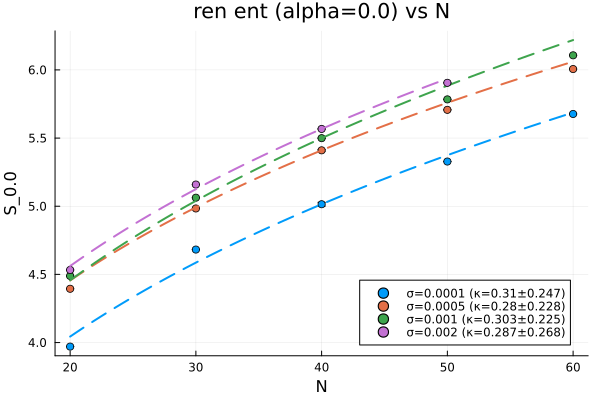

In [26]:
N_vals = 20:10:60
sigma_vals = [0.0001, 0.0005, 0.001, 0.002]

p05 = plot_renyi(N_vals, sigma_vals, 0.5)
p01 = plot_renyi(N_vals, sigma_vals, 0.1)
p20 = plot_renyi(N_vals, sigma_vals, 2.0)
p10 = plot_renyi(N_vals, sigma_vals, 1.0)
p00 = plot_renyi(N_vals, sigma_vals, 0.0) 

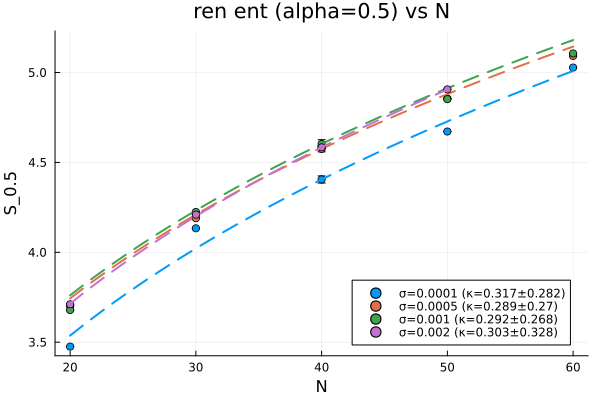

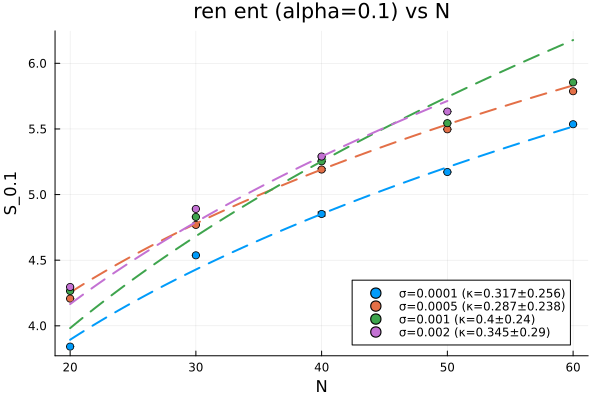

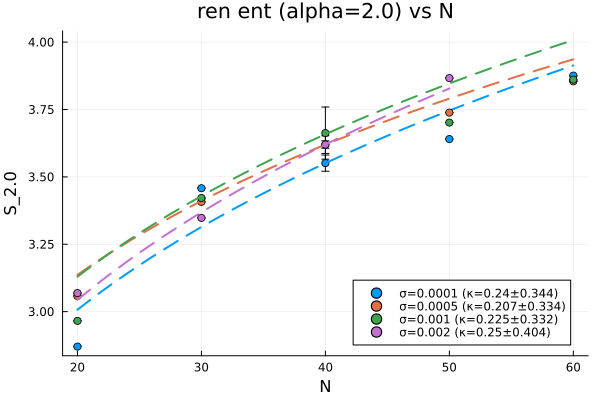

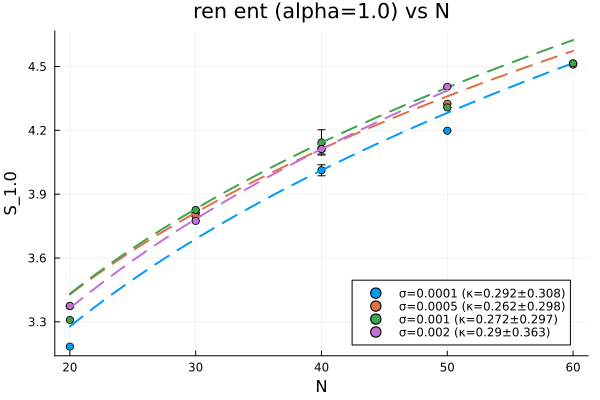

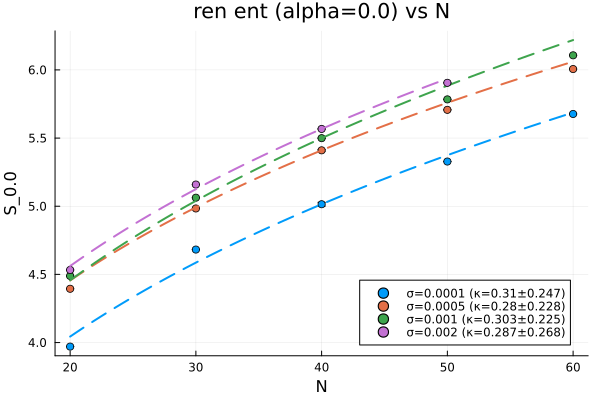

In [27]:
display(p05)
display(p01)
display(p20)
display(p10)
display(p00)